# Taylor Series

A Taylor series generalizes the Maclaurin series by allowing the expansion to be centered at an arbitrary point $x_0$. For a sufficiently differentiable function $f(x)$, the Taylor expansion about $x_0$ is

$$
f(x) = \sum_{n=0}^{\infty}\frac{f^{(n)}(x_0)}{n!}(x-x_0)^n.
$$

A finite number of terms provides a polynomial approximation that is generally most accurate near the expansion point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Taylor Expansion of $\cos(x)$

Consider

$$
f(x) = \cos(x)
$$

with the expansion centered at

$$
x_0 = \pi.
$$

The derivatives of $\cos(x)$ evaluated at $\pi$ give

$$
\cos(x) = -1 + \frac{(x-\pi)^2}{2!} - \frac{(x-\pi)^4}{4!} + \frac{(x-\pi)^6}{6!} - \frac{(x-\pi)^8}{8!} + \cdots.
$$

Using terms up to degree $8$ gives the polynomial approximation

$$
P_8(x) = -1 +\frac{(x-\pi)^2}{2} - \frac{(x-\pi)^4}{24} + \frac{(x-\pi)^6}{720} - \frac{(x-\pi)^8}{40320}.
$$

In [3]:
x = np.linspace(0, 2 * np.pi, 1000)
f = np.cos(x)
deg = 8

## Polynomial Representation

To represent the Taylor polynomial using `np.polynomial.Polynomial`, the variable is shifted to the expansion point:

$$
z = x - \pi.
$$

The polynomial is therefore expressed in terms of $z$ as

$$
P_8(z) = -1 + \frac{1}{2}z^2 - \frac{1}{24}z^4 + \frac{1}{720}z^6 - \frac{1}{40320}z^8.
$$

This shift is implemented by fitting the polynomial to `x - np.pi`. The resulting polynomial is then evaluated using the same shifted variable.

In [4]:
P = np.polynomial.Polynomial.fit(x - np.pi, f, deg=deg)
P

Polynomial([-9.99970820e-01,  1.94395649e-15,  4.93318733e+00, -5.49735871e-15,
       -4.04457195e+00,  1.52388399e-14,  1.29205392e+00, -1.00833090e-14,
       -1.80806306e-01], domain=[-3.14159265,  3.14159265], window=[-1.,  1.], symbol='x')

## Coefficient Verification

The coefficients of the polynomial in the shifted coordinate $z = x - \pi$ are

$$
\left[-1, 0, \frac{1}{2}, 0, -\frac{1}{24}, 0, \frac{1}{720}, 0, -\frac{1}{40320}\right].
$$

These coefficients are compared with the analytical Taylor coefficients using `np.allclose`, allowing for small numerical differences introduced by the polynomial fitting procedure.

In [5]:
np.allclose(P.convert().coef, np.array([-1, 0, 1/2, 0, -1/24, 0, 1/720, 0, -1/40320]), rtol=1e-3, atol=1e-3)

True

## Approximation

The original function and its degree-$8$ Taylor approximation are evaluated over the interval $[0,2\pi]$. The approximation is centered at $x=\pi$, so the polynomial reproduces the behavior of $\cos(x)$ most accurately near this point. As the distance from the expansion point increases, the truncation error generally becomes more noticeable.

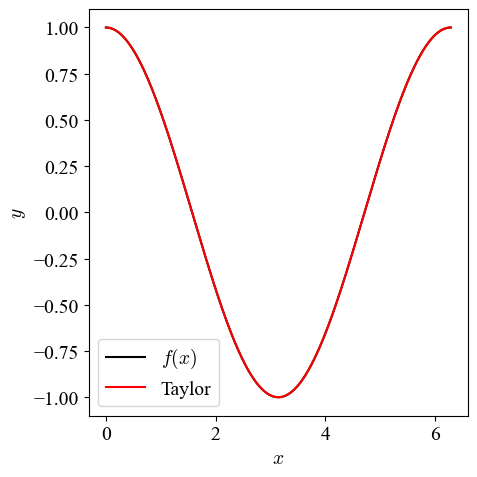

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(x, f, "k", label=r"$f(x)$")
plt.plot(x, P(x - np.pi), "r", label="Taylor")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

This illustrates the key distinction between the two expansions: a Maclaurin series is a Taylor series centered at $x_0=0$, whereas a Taylor series can be centered at any point $x_0$.